**Project Overview**

At its core, this dataset will let us train a CNN (Convolutional Neural Network) to automatically recognize and classify different types of vegetables from images. The model will learn visual features like shape, color, and texture, and then predict which class (e.g., Carrot, Tomato, Cabbage) a new image belongs to.

This kind of classification has several practical uses. For example,


1. It can be used in smart agriculture systems to automatically identify crops and assist farmers in sorting or monitoring produce.
2. In supermarkets or warehouses, it can power automated checkout systems or sorting machines that recognize vegetables without manual labeling.
3. It can also be integrated into mobile applications where users take a picture to identify vegetables, useful for cooking, shopping, or educational purposes.
4. It can support quality control systems when combined with further training (e.g., detecting spoiled vs fresh vegetables).
Overall, the purpose is to replace manual identification with a fast, consistent, and scalable automated solution.



**Import Necessary Libraries**

In [35]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras import layers, models, Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


**Upload the dataset**

In [36]:
data_dir = "/kaggle/input/datasets/namunaregmi/assessment-vegetables/Vegetable Images"

train_dir = os.path.join(data_dir, "train")
val_dir   = os.path.join(data_dir, "validation")
test_dir  = os.path.join(data_dir, "test")

print("Train dir:", train_dir)
print("Val dir:  ", val_dir)
print("Test dir: ", test_dir)

Train dir: /kaggle/input/datasets/namunaregmi/assessment-vegetables/Vegetable Images/train
Val dir:   /kaggle/input/datasets/namunaregmi/assessment-vegetables/Vegetable Images/validation
Test dir:  /kaggle/input/datasets/namunaregmi/assessment-vegetables/Vegetable Images/test


3. Data Understanding, Analysis, Visualisation and Cleaning

3.1 Dataset Structure

In [37]:
def show_structure(path, level=0):
    """Recursively display directory structure."""
    for item in sorted(os.listdir(path)):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            print("  " * level + "|-- " + item)
            show_structure(item_path, level + 1)

print("Dataset hierarchy (directories only):")
show_structure(data_dir)

Dataset hierarchy (directories only):
|-- test
  |-- Bean
  |-- Bitter_Gourd
  |-- Bottle_Gourd
  |-- Brinjal
  |-- Broccoli
  |-- Cabbage
  |-- Capsicum
  |-- Carrot
  |-- Cauliflower
  |-- Cucumber
  |-- Papaya
  |-- Potato
  |-- Pumpkin
  |-- Radish
  |-- Tomato
|-- train
  |-- Bean
  |-- Bitter_Gourd
  |-- Bottle_Gourd
  |-- Brinjal
  |-- Broccoli
  |-- Cabbage
  |-- Capsicum
  |-- Carrot
  |-- Cauliflower
  |-- Cucumber
  |-- Papaya
  |-- Potato
  |-- Pumpkin
  |-- Radish
  |-- Tomato
|-- validation
  |-- Bean
  |-- Bitter_Gourd
  |-- Bottle_Gourd
  |-- Brinjal
  |-- Broccoli
  |-- Cabbage
  |-- Capsicum
  |-- Carrot
  |-- Cauliflower
  |-- Cucumber
  |-- Papaya
  |-- Potato
  |-- Pumpkin
  |-- Radish
  |-- Tomato


**Image Count Per Class**

In [38]:
def count_images(folder_path):
    """Return dict {class_name: image_count} for all subdirectories."""
    counts = {}
    for cls in sorted(os.listdir(folder_path)):
        cls_path = os.path.join(folder_path, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
            ])
    return counts

train_counts = count_images(train_dir)
val_counts   = count_images(val_dir)
test_counts  = count_images(test_dir)

print(f"Total Training Images  : {sum(train_counts.values())}")
print(f"Total Validation Images: {sum(val_counts.values())}")
print(f"Total Testing Images   : {sum(test_counts.values())}")
print(f"Number of Classes      : {len(train_counts)}")
print(f"Classes                : {list(train_counts.keys())}")

Total Training Images  : 15000
Total Validation Images: 3000
Total Testing Images   : 3000
Number of Classes      : 15
Classes                : ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']


Class Distribution (Bar Chart)

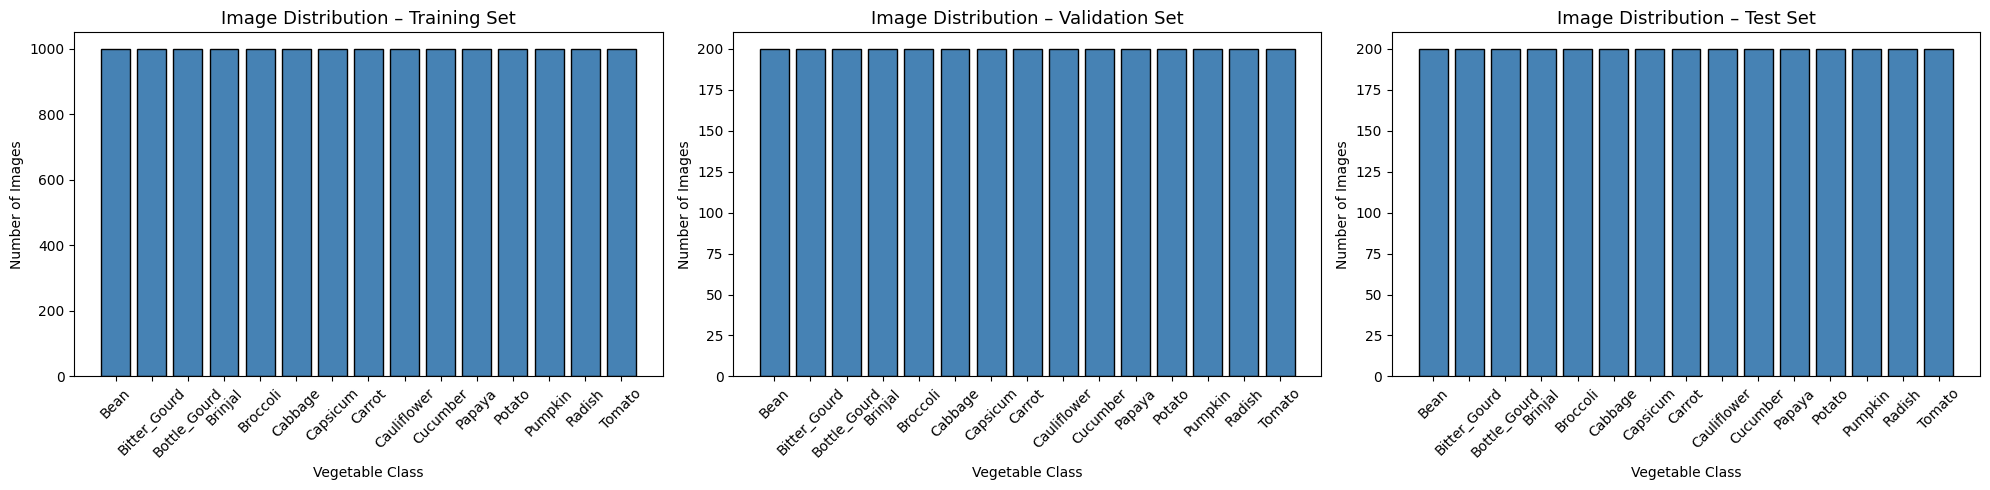


Class with fewest training images: Bean (1000)
Class with most training images  : Bean (1000)
Imbalance ratio (max/min)        : 1.00


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (counts, title) in zip(axes, [
    (train_counts, "Training Set"),
    (val_counts,   "Validation Set"),
    (test_counts,  "Test Set")
]):
    ax.bar(counts.keys(), counts.values(), color='steelblue', edgecolor='black')
    ax.set_title(f"Image Distribution – {title}", fontsize=13)
    ax.set_xlabel("Vegetable Class")
    ax.set_ylabel("Number of Images")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Check for class imbalance
min_cls = min(train_counts, key=train_counts.get)
max_cls = max(train_counts, key=train_counts.get)
print(f"\nClass with fewest training images: {min_cls} ({train_counts[min_cls]})")
print(f"Class with most training images  : {max_cls} ({train_counts[max_cls]})")
imbalance_ratio = train_counts[max_cls] / train_counts[min_cls]
print(f"Imbalance ratio (max/min)        : {imbalance_ratio:.2f}")

**Dataset Split Distribution (Pie Chart)**

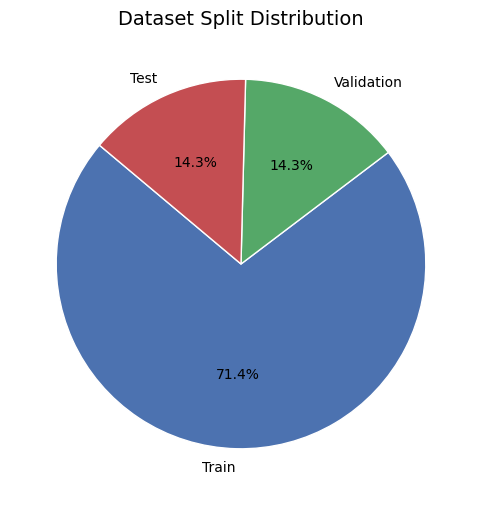


Dataset Split Justification:
  Train: 15000 images (71.4%)
  Validation: 3000 images (14.3%)
  Test: 3000 images (14.3%)

The 70/15/15 split is standard practice: a large training set maximises learning, while separate validation and test sets provide unbiased performance estimates during and after training.


In [40]:
sizes  = [sum(train_counts.values()), sum(val_counts.values()), sum(test_counts.values())]
labels = ["Train", "Validation", "Test"]
colors = ['#4C72B0', '#55A868', '#C44E52']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors,
        startangle=140, wedgeprops=dict(edgecolor='white'))
plt.title("Dataset Split Distribution", fontsize=14)
plt.show()

total = sum(sizes)
print("\nDataset Split Justification:")
for label, s in zip(labels, sizes):
    print(f"  {label}: {s} images ({100*s/total:.1f}%)")
print("\nThe 70/15/15 split is standard practice: a large training set",
      "maximises learning, while separate validation and test sets",
      "provide unbiased performance estimates during and after training.")

**Sample Images From Each Class**

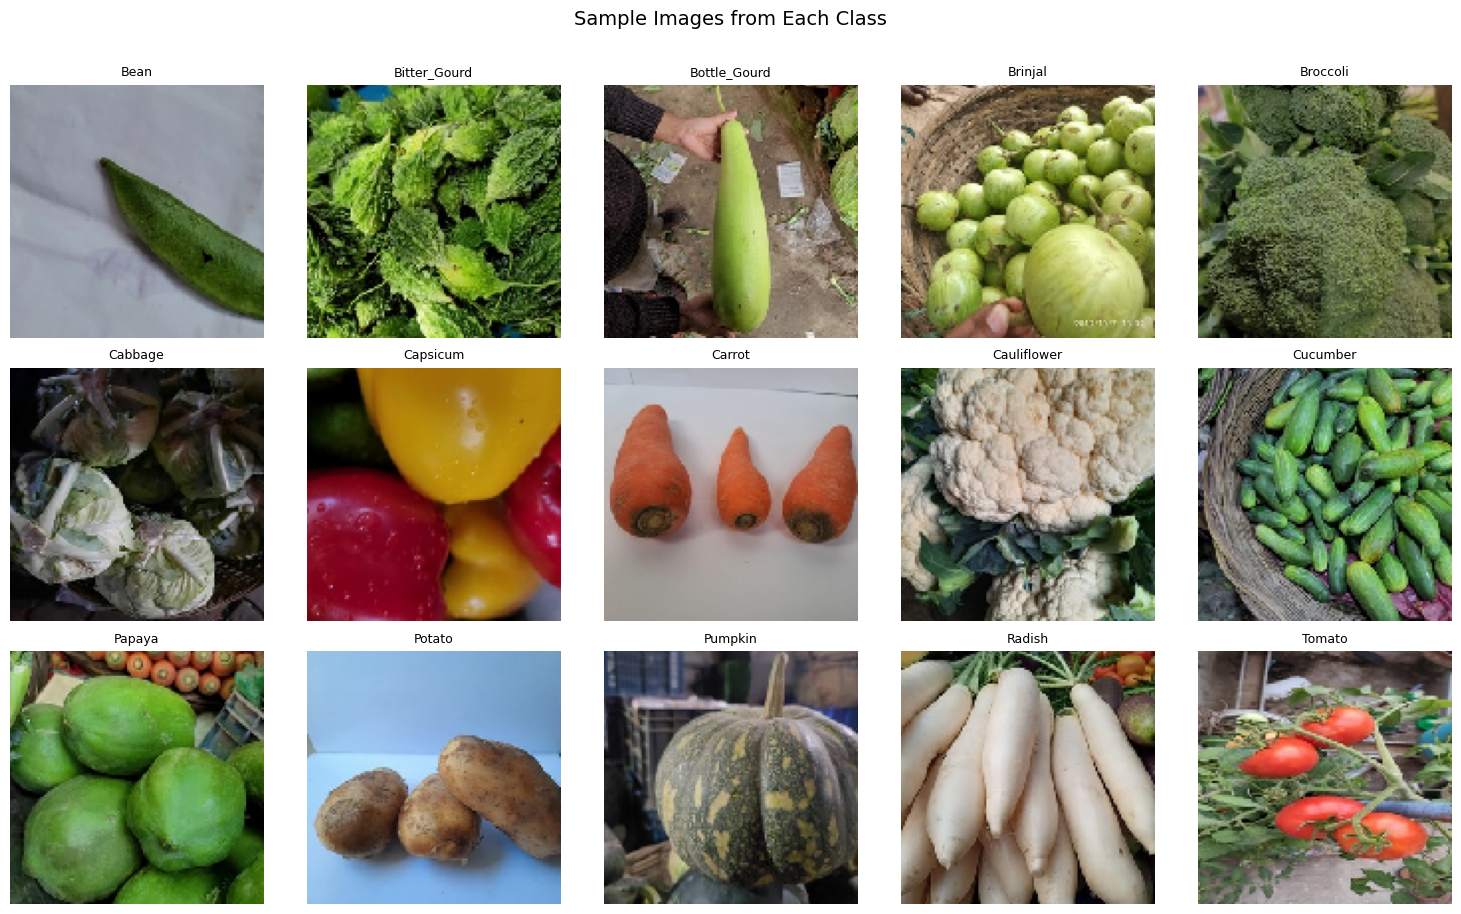

In [41]:
class_names = list(train_counts.keys())
n_classes   = len(class_names)
cols        = 5
rows        = (n_classes + cols - 1) // cols

plt.figure(figsize=(cols * 3, rows * 3))
for i, cls in enumerate(class_names):
    cls_path = os.path.join(train_dir, cls)
    img_file = os.listdir(cls_path)[0]          # first image
    img      = load_img(os.path.join(cls_path, img_file), target_size=(128, 128))
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(cls, fontsize=9)
    plt.axis('off')

plt.suptitle("Sample Images from Each Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Data Generators with Augmentation**

**Preprocessing applied:**
- Resize all images to **224 × 224** pixels (compatible with pretrained ImageNet models in Part B).
- **Pixel normalisation** to [0, 1] via `rescale=1./255`.

**Augmentation applied to training set only:**
- `rotation_range=20` – slight rotational variance
- `zoom_range=0.2` – moderate zoom
- `horizontal_flip=True` – mirror flipping
- `width_shift_range=0.1`, `height_shift_range=0.1` – small translations

No augmentation is applied to validation or test sets to ensure unbiased evaluation.

In [42]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# ── Training generator (with augmentation) ──────────────────────────────────
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# ── Validation / Test generators (normalisation only) ───────────────────────
val_gen  = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

val_data = val_gen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

test_data = test_gen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

NUM_CLASSES = train_data.num_classes
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class indices: {train_data.class_indices}")

Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Number of classes: 15
Class indices: {'Bean': 0, 'Bitter_Gourd': 1, 'Bottle_Gourd': 2, 'Brinjal': 3, 'Broccoli': 4, 'Cabbage': 5, 'Capsicum': 6, 'Carrot': 7, 'Cauliflower': 8, 'Cucumber': 9, 'Papaya': 10, 'Potato': 11, 'Pumpkin': 12, 'Radish': 13, 'Tomato': 14}


**Visualize Augmented Images**

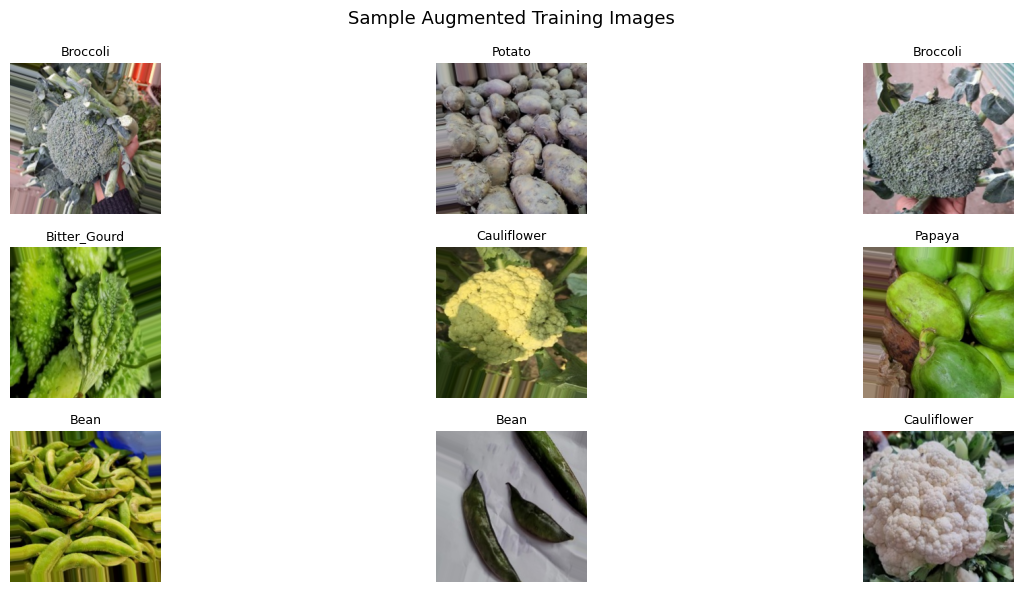

In [43]:
images_aug, labels_aug = next(train_data)
label_keys = {v: k for k, v in train_data.class_indices.items()}

plt.figure(figsize=(15, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images_aug[i])
    cls_idx = np.argmax(labels_aug[i])
    plt.title(label_keys[cls_idx], fontsize=9)
    plt.axis('off')
plt.suptitle("Sample Augmented Training Images", fontsize=13)
plt.tight_layout()
plt.show()

Original vs Augmented Images

Found 15000 images belonging to 15 classes.


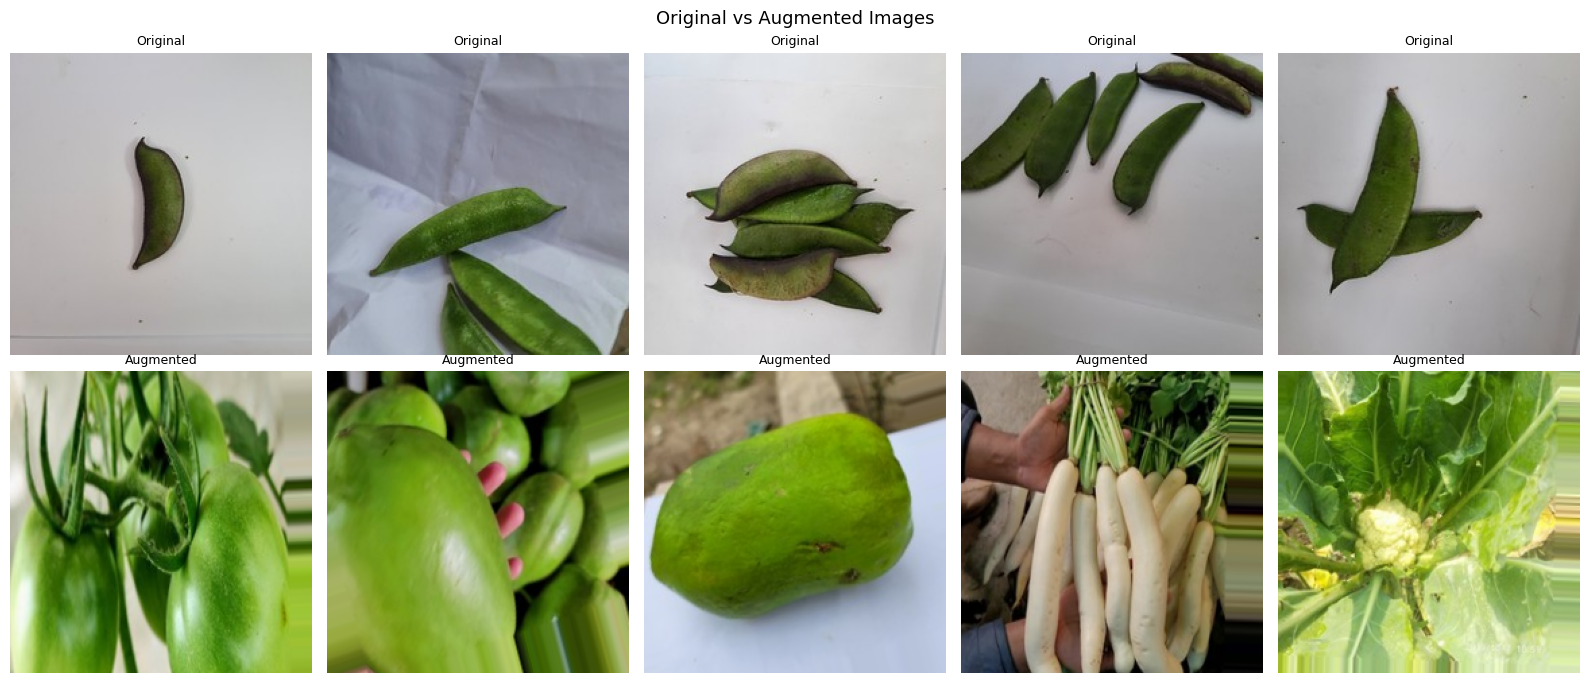

In [44]:
original_gen = ImageDataGenerator(rescale=1./255)
original_data = original_gen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

orig_images, _ = next(original_data)
aug_images, _  = next(train_data)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i in range(5):
    axes[0, i].imshow(orig_images[i])
    axes[0, i].set_title("Original", fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(aug_images[i])
    axes[1, i].set_title("Augmented", fontsize=9)
    axes[1, i].axis('off')

plt.suptitle("Original vs Augmented Images", fontsize=13)
plt.tight_layout()
plt.show()

**Part A : CNN from Scratch**

Baseline CNN Model

Model Architecture


| MaxPool | – | 2×2 | – |
| Conv2D | 64 | 3×3 | 
| Layer | Filters / Units | Kernel | Activation |
|-------|----------------|--------|------------|
| Conv2D | 32 | 3×ReLU |
| MaxPool | – | 2×2 | – |
| Conv2D | 128 | 3×3 | ReLU |
| MaxPool | – | 2×2 | – |
| Dense | 128 | – | ReLU |
| Dense | 64 | – | ReLU |
| Dense | 32 | – | ReLU |
| Output | NUM_CLASSES | – | Softmax |

In [45]:
def build_baseline_model(num_classes):
    model = models.Sequential([
        # --- Conv Block 1 ---
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.MaxPooling2D(2, 2),

        # --- Conv Block 2 ---
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # --- Conv Block 3 ---
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # --- Fully Connected Layers ---
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),
        layers.Dense(32,  activation='relu'),

        # --- Output ---
        layers.Dense(num_classes, activation='softmax')
    ], name="Baseline_CNN")
    return model

model_baseline = build_baseline_model(NUM_CLASSES)
model_baseline.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_baseline.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,179,791 (42.65 MB)

 Trainable params: 11,179,791 (42.65 MB)

 Non-trainable params: 0 (0.00 B)

Train Baseline

In [46]:
# Callbacks
early_stop_baseline = EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)

start_baseline = time.time()

history_baseline = model_baseline.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop_baseline]
)

baseline_time = time.time() - start_baseline
print(f"\nBaseline Training Time: {baseline_time:.1f} seconds ({baseline_time/60:.1f} min)")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


2026-05-14 05:54:13.249909: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 05:54:13.399217: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


458/469 ━━━━━━━━━━━━━━━━━━━━ 6s 554ms/step - accuracy: 0.2915 - loss: 2.1145

2026-05-14 05:58:31.829148: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 05:58:31.978706: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


469/469 ━━━━━━━━━━━━━━━━━━━━ 299s 621ms/step - accuracy: 0.2952 - loss: 2.1029 - val_accuracy: 0.6240 - val_loss: 1.0499
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 179s 382ms/step - accuracy: 0.6431 - loss: 1.0516 - val_accuracy: 0.7893 - val_loss: 0.6306
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 179s 382ms/step - accuracy: 0.7823 - loss: 0.6496 - val_accuracy: 0.8783 - val_loss: 0.4081
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 179s 382ms/step - accuracy: 0.8464 - loss: 0.4681 - val_accuracy: 0.9080 - val_loss: 0.3108
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 180s 384ms/step - accuracy: 0.8813 - loss: 0.3708 - val_accuracy: 0.8967 - val_loss: 0.3502
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 182s 387ms/step - accuracy: 0.9010 - loss: 0.3130 - val_accuracy: 0.9377 - val_loss: 0.2374
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 179s 381ms/step - accuracy: 0.9092 - loss: 0.2867 - val_accuracy: 0.9433 - val_loss: 0.1894
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 175s 373ms/step - accuracy: 0.9252 - loss: 0.23

In [47]:
model_baseline.save("baseline_model.h5")

Training vs Validation Loss and Accuracy Curves

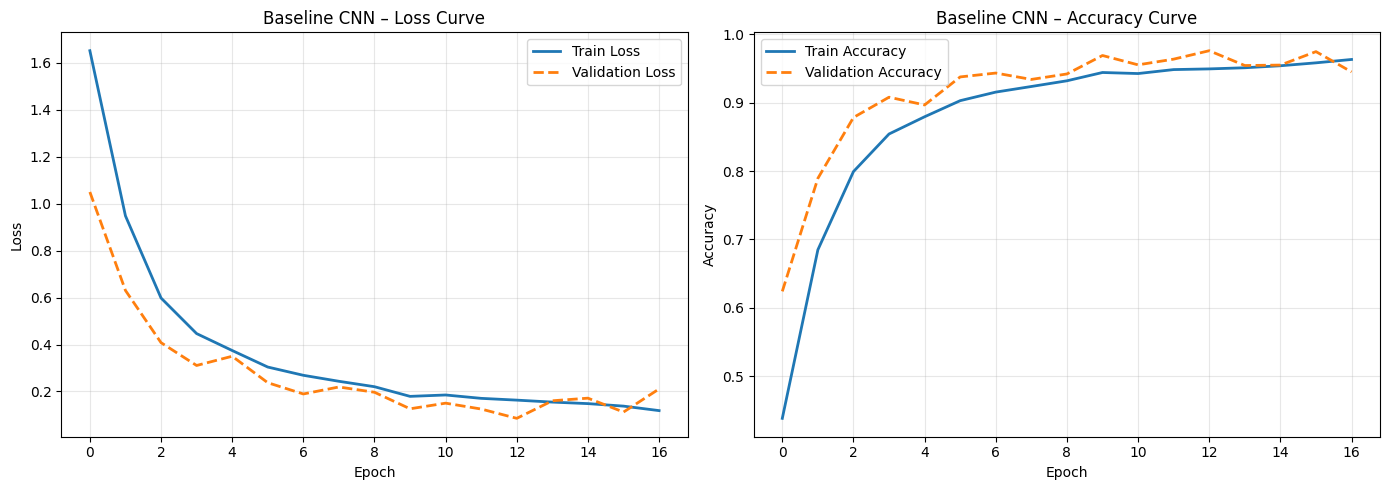

In [48]:
def plot_history(history, title="Model"):
    """Plot training vs validation loss and accuracy."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history.history['loss'],     label='Train Loss',      linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
    axes[0].set_title(f"{title} – Loss Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'],     label='Train Accuracy',      linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--')
    axes[1].set_title(f"{title} – Accuracy Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_baseline, "Baseline CNN")

Baseline Model Evaluation


  Baseline CNN – Test Evaluation
  Test Loss    : 0.0935
  Test Accuracy: 0.9763 (97.63%)

Classification Report:
              precision    recall  f1-score   support

        Bean       0.97      0.97      0.97       200
Bitter_Gourd       0.99      0.98      0.98       200
Bottle_Gourd       0.98      0.98      0.98       200
     Brinjal       0.97      0.98      0.98       200
    Broccoli       0.94      0.98      0.96       200
     Cabbage       0.98      0.94      0.96       200
    Capsicum       1.00      0.98      0.99       200
      Carrot       0.99      1.00      0.99       200
 Cauliflower       0.96      0.94      0.95       200
    Cucumber       0.99      0.98      0.99       200
      Papaya       0.97      0.97      0.97       200
      Potato       1.00      0.98      0.99       200
     Pumpkin       0.97      0.98      0.98       200
      Radish       0.98      1.00      0.99       200
      Tomato       0.96      0.95      0.96       200

    accuracy       

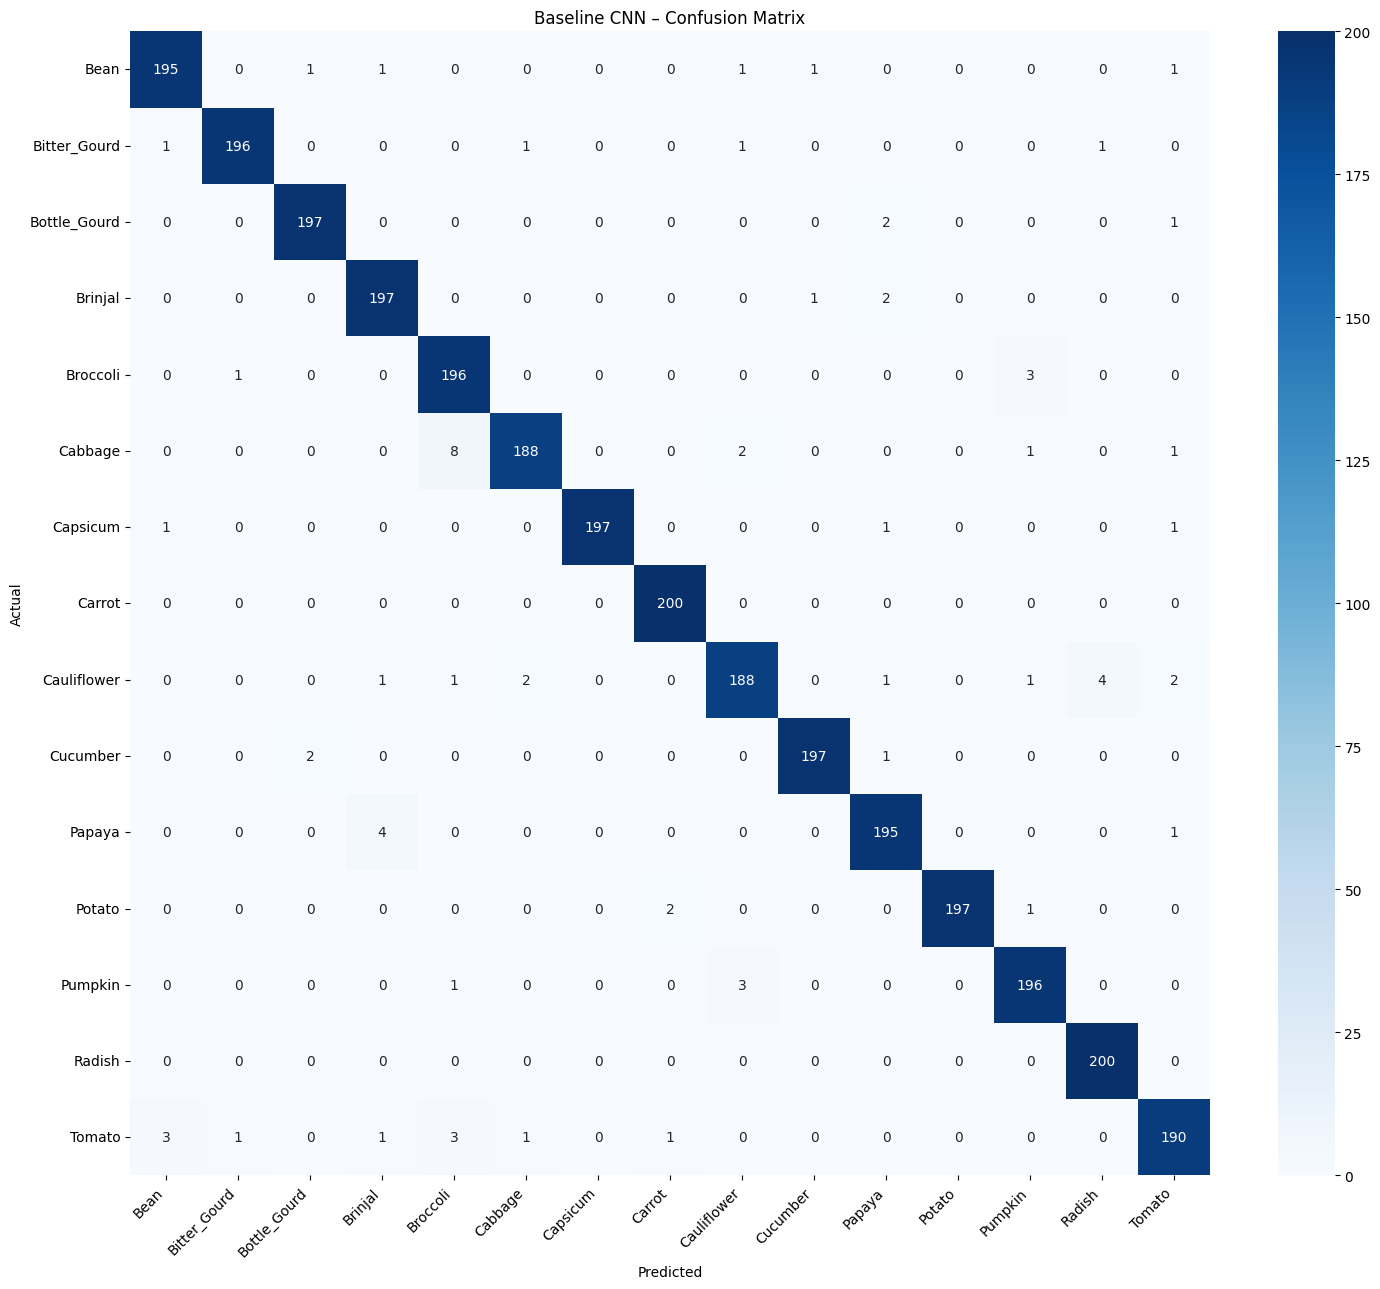

In [49]:
def evaluate_model(model, test_data, model_name="Model"):
    """Full evaluation: loss, accuracy, confusion matrix, classification report."""
    test_data.reset()
    loss, acc = model.evaluate(test_data, verbose=0)
    print(f"\n{'='*50}")
    print(f"  {model_name} – Test Evaluation")
    print(f"{'='*50}")
    print(f"  Test Loss    : {loss:.4f}")
    print(f"  Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

    # Predictions
    test_data.reset()
    y_pred_probs = model.predict(test_data, verbose=0)
    y_pred  = np.argmax(y_pred_probs, axis=1)
    y_true  = test_data.classes
    classes = list(test_data.class_indices.keys())

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(8, len(classes)), max(6, len(classes)-2)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f"{model_name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return loss, acc, y_pred, y_true

baseline_loss, baseline_acc, baseline_preds, y_true = evaluate_model(
    model_baseline, test_data, "Baseline CNN")

Inference on Sample Test Images

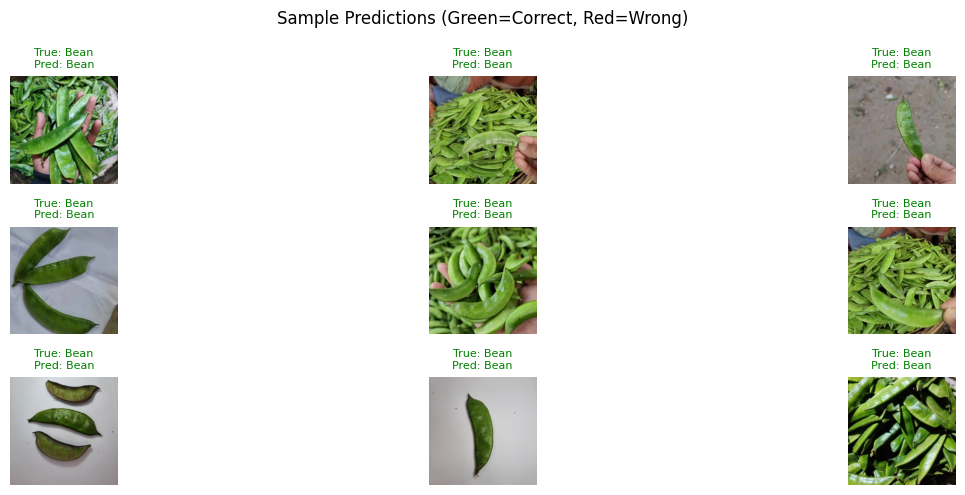

In [50]:
def infer_samples(model, test_data, n=9):
    """Show sample predictions with true vs predicted labels."""
    classes = list(test_data.class_indices.keys())
    test_data.reset()
    imgs, lbls = next(test_data)
    preds = np.argmax(model.predict(imgs, verbose=0), axis=1)
    trues = np.argmax(lbls, axis=1)

    plt.figure(figsize=(15, 5))
    for i in range(min(n, len(imgs))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(imgs[i])
        color = 'green' if preds[i] == trues[i] else 'red'
        plt.title(f"True: {classes[trues[i]]}\nPred: {classes[preds[i]]}",
                  color=color, fontsize=8)
        plt.axis('off')
    plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=12)
    plt.tight_layout()
    plt.show()

infer_samples(model_baseline, test_data)

**Deeper Model Architecture with Regularization**

The deeper model doubles the number of convolutional layers (6 Conv blocks vs 3) and adds regularisation:
- **BatchNormalization** after each Conv layer → stabilises and accelerates training
- **Dropout** in Dense layers → reduces overfitting

| Layer | Filters / Units | Kernel | Activation | Regularisation |
|-------|----------------|--------|------------|----------------|
| Conv2D | 32 | 3×3 | ReLU | – |
| BatchNorm | – | – | – | ✓ |
| MaxPool | – | 2×2 | – | – |
| Conv2D | 64 | 3×3 | ReLU | – |
| BatchNorm | – | – | – | ✓ |
| MaxPool | – | 2×2 | – | – |
| Conv2D | 128 | 3×3 | ReLU | – |
| BatchNorm | – | – | – | ✓ |
| MaxPool | – | 2×2 | – | – |
| Conv2D | 256 | 3×3 | ReLU | – |
| BatchNorm | – | – | – | ✓ |
| MaxPool | – | 2×2 | – | – |
| Conv2D | 256 | 3×3 | ReLU | – |
| BatchNorm | – | – | – | ✓ |
| Conv2D | 512 | 3×3 | ReLU | – |
| BatchNorm | – | – | – | ✓ |
| GlobalAvgPool | – | – | – | – |
| Dense | 512 | – | ReLU | Dropout(0.5) |
| Dense | 256 | – | ReLU | Dropout(0.4) |
| Dense | 128 | – | ReLU | Dropout(0.3) |
| Output | NUM_CLASSES | – | Softmax | – |

In [75]:
def build_deep_model(num_classes):
    model = models.Sequential([
        # --- Conv Block 1 ---
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # --- Conv Block 2 ---
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # --- Conv Block 3 ---
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # --- Conv Block 4 ---
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # --- Conv Block 5 (no pooling – spatial dims already small) ---
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),

        # --- Conv Block 6 ---
        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),

        # --- Global Average Pooling (replaces large Flatten) ---
        layers.GlobalAveragePooling2D(),

        # --- Dense Layers with Dropout ---
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        # --- Output ---
        layers.Dense(num_classes, activation='softmax')
    ], name="Deep_Regularised_CNN")
    return model

model_deep = build_deep_model(NUM_CLASSES)
model_deep.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_deep.summary()

Model: "Deep_Regularised_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_72 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 14, 14, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,592,463 (9.89 MB)

 Trainable params: 2,589,967 (9.88 MB)

 Non-trainable params: 2,496 (9.75 KB)

Training the deeper model

In [52]:
early_stop_deep = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

start_deep = time.time()

history_deep = model_deep.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop_deep]
)

deep_time = time.time() - start_deep
print(f"\nDeep Model Training Time: {deep_time:.1f} seconds ({deep_time/60:.1f} min)")

Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 223s 440ms/step - accuracy: 0.3856 - loss: 1.9266 - val_accuracy: 0.3367 - val_loss: 2.4987
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 184s 392ms/step - accuracy: 0.6888 - loss: 0.9711 - val_accuracy: 0.6127 - val_loss: 1.3309
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 185s 395ms/step - accuracy: 0.7848 - loss: 0.6967 - val_accuracy: 0.8267 - val_loss: 0.5644
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 184s 393ms/step - accuracy: 0.8501 - loss: 0.5196 - val_accuracy: 0.8177 - val_loss: 0.6206
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 186s 396ms/step - accuracy: 0.8872 - loss: 0.4104 - val_accuracy: 0.9170 - val_loss: 0.2595
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 409ms/step - accuracy: 0.9036 - loss: 0.3574 - val_accuracy: 0.8360 - val_loss: 0.5853
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 193s 411ms/step - accuracy: 0.9236 - loss: 0.2876 - val_accuracy: 0.9170 - val_loss: 0.3031
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 407ms/step - accuracy: 0.9332 -

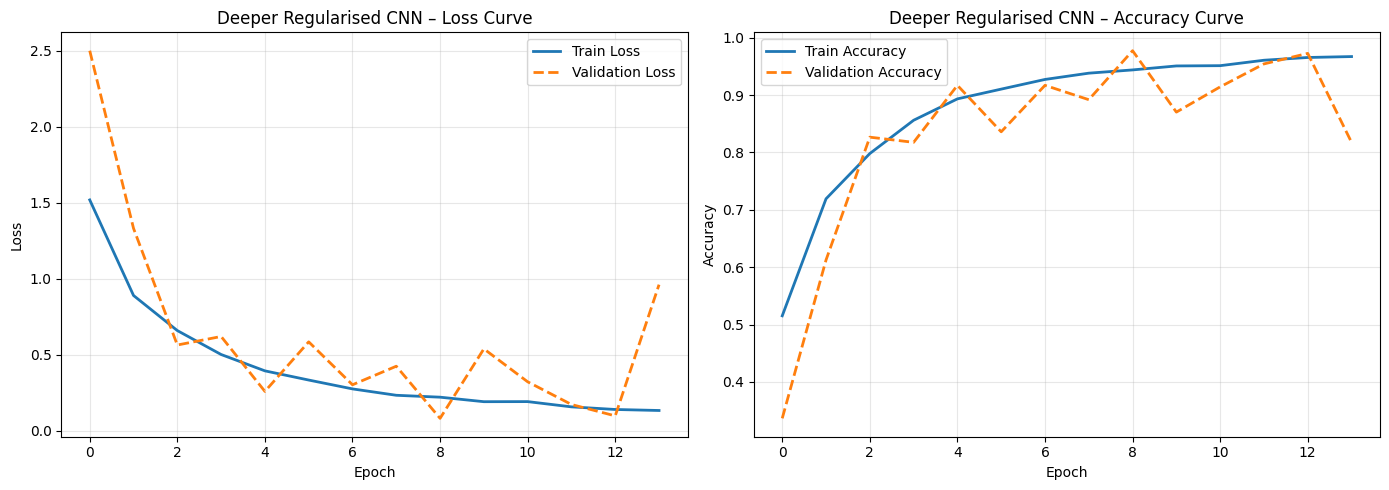

In [53]:
plot_history(history_deep, "Deeper Regularised CNN")

In [54]:
model_deep.save("deep_model.keras")

Deeper Model Evaluation


  Deeper Regularised CNN – Test Evaluation
  Test Loss    : 0.0878
  Test Accuracy: 0.9790 (97.90%)

Classification Report:
              precision    recall  f1-score   support

        Bean       0.99      0.96      0.98       200
Bitter_Gourd       0.98      0.99      0.98       200
Bottle_Gourd       0.98      0.99      0.99       200
     Brinjal       0.99      0.97      0.98       200
    Broccoli       0.97      0.97      0.97       200
     Cabbage       0.95      0.99      0.97       200
    Capsicum       0.98      0.98      0.98       200
      Carrot       0.98      0.99      0.99       200
 Cauliflower       0.97      0.97      0.97       200
    Cucumber       0.98      0.96      0.97       200
      Papaya       0.98      0.99      0.99       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       0.97      0.97      0.97       200
      Radish       0.98      0.98      0.98       200
      Tomato       0.99      0.93      0.96       200

    accur

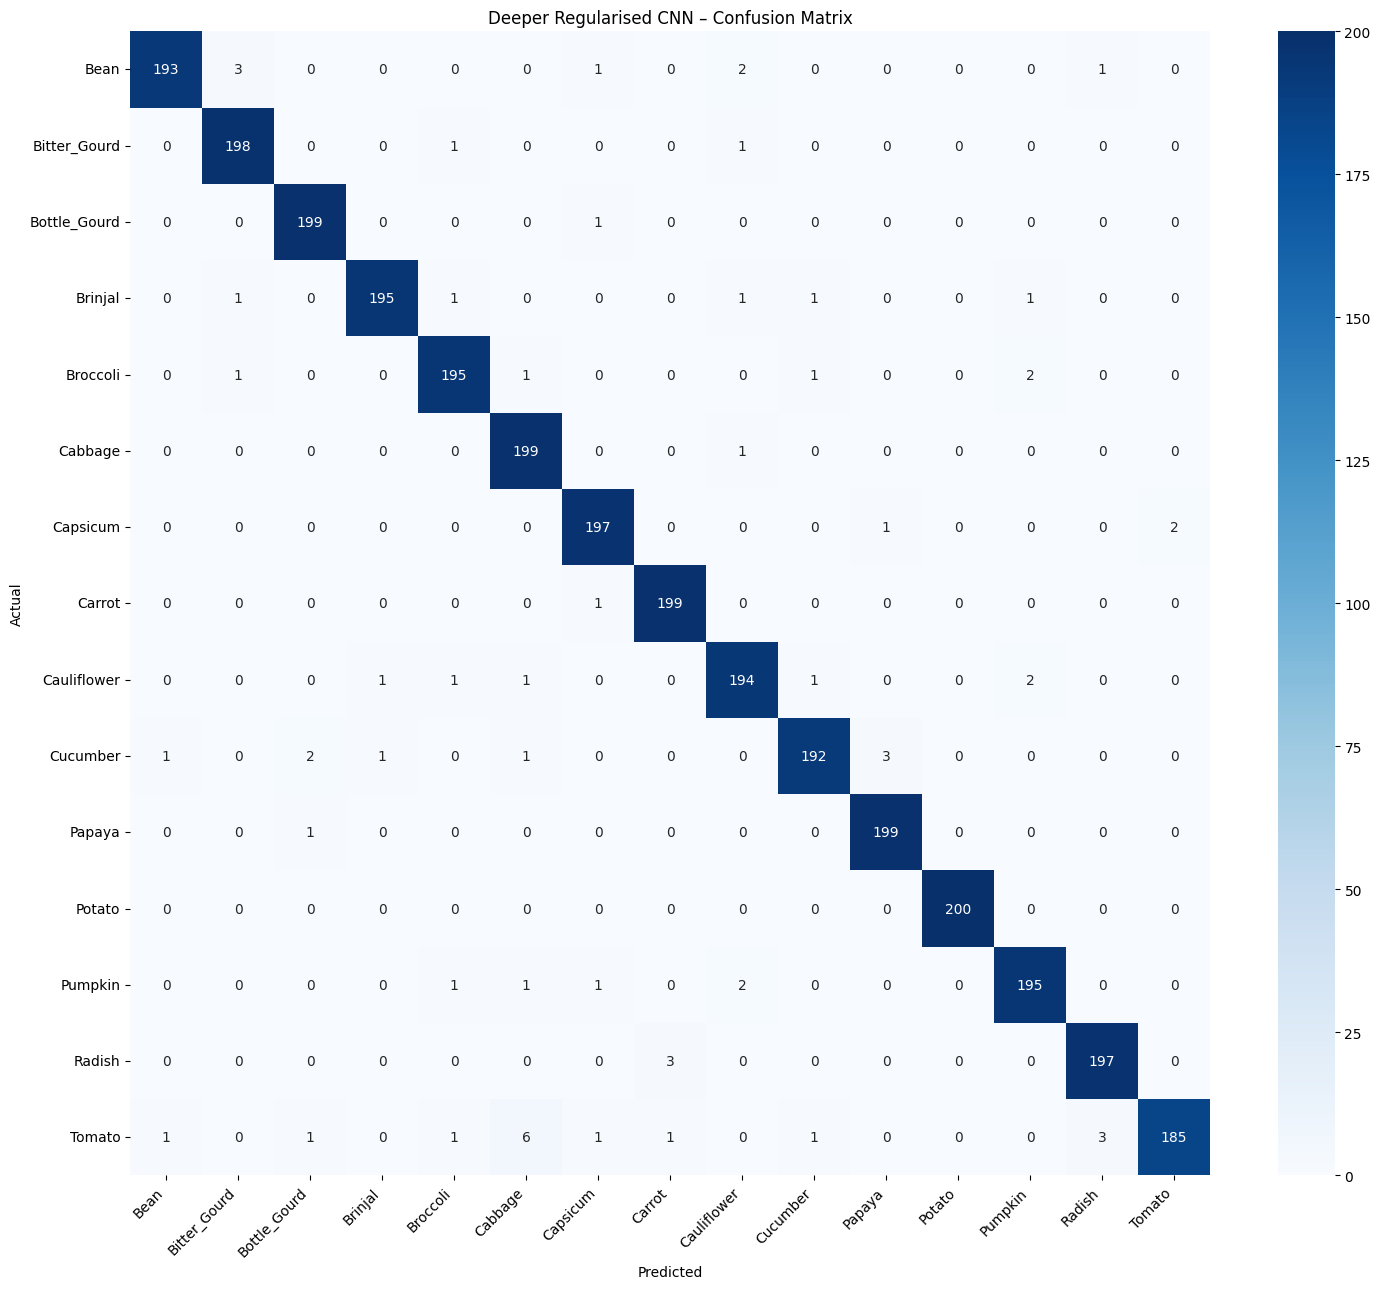

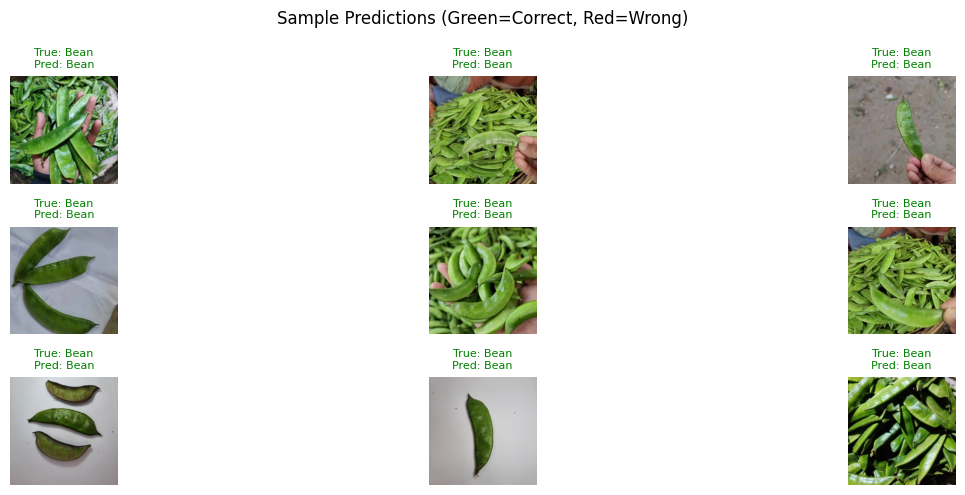

In [55]:
deep_loss, deep_acc, deep_preds, _ = evaluate_model(
    model_deep, test_data, "Deeper Regularised CNN")

infer_samples(model_deep, test_data)

Experimentation and Comparative Analysis

Baseline vs Deeper Model

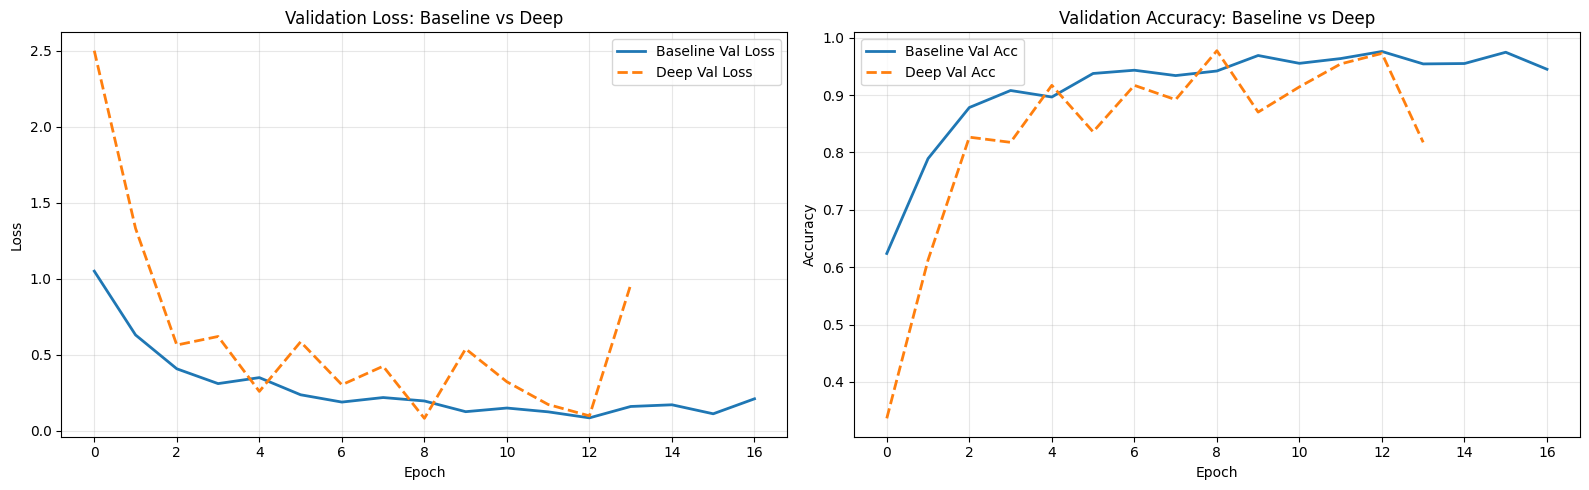


Metric                           Baseline       Deep
-------------------------------------------------------
Test Accuracy                      0.9763     0.9790
Test Loss                          0.0935     0.0878
Training Time (s)                  3158.0     2664.9
Epochs Trained                         17         14


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss comparison
axes[0].plot(history_baseline.history['val_loss'], label='Baseline Val Loss',   linewidth=2)
axes[0].plot(history_deep.history['val_loss'],     label='Deep Val Loss',       linewidth=2, linestyle='--')
axes[0].set_title("Validation Loss: Baseline vs Deep")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(history_baseline.history['val_accuracy'], label='Baseline Val Acc', linewidth=2)
axes[1].plot(history_deep.history['val_accuracy'],     label='Deep Val Acc',     linewidth=2, linestyle='--')
axes[1].set_title("Validation Accuracy: Baseline vs Deep")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*55)
print(f"{'Metric':<30} {'Baseline':>10} {'Deep':>10}")
print("-"*55)
print(f"{'Test Accuracy':<30} {baseline_acc:>10.4f} {deep_acc:>10.4f}")
print(f"{'Test Loss':<30} {baseline_loss:>10.4f} {deep_loss:>10.4f}")
print(f"{'Training Time (s)':<30} {baseline_time:>10.1f} {deep_time:>10.1f}")
print(f"{'Epochs Trained':<30} {len(history_baseline.history['loss']):>10} {len(history_deep.history['loss']):>10}")
print("="*55)

Computational Efficiency

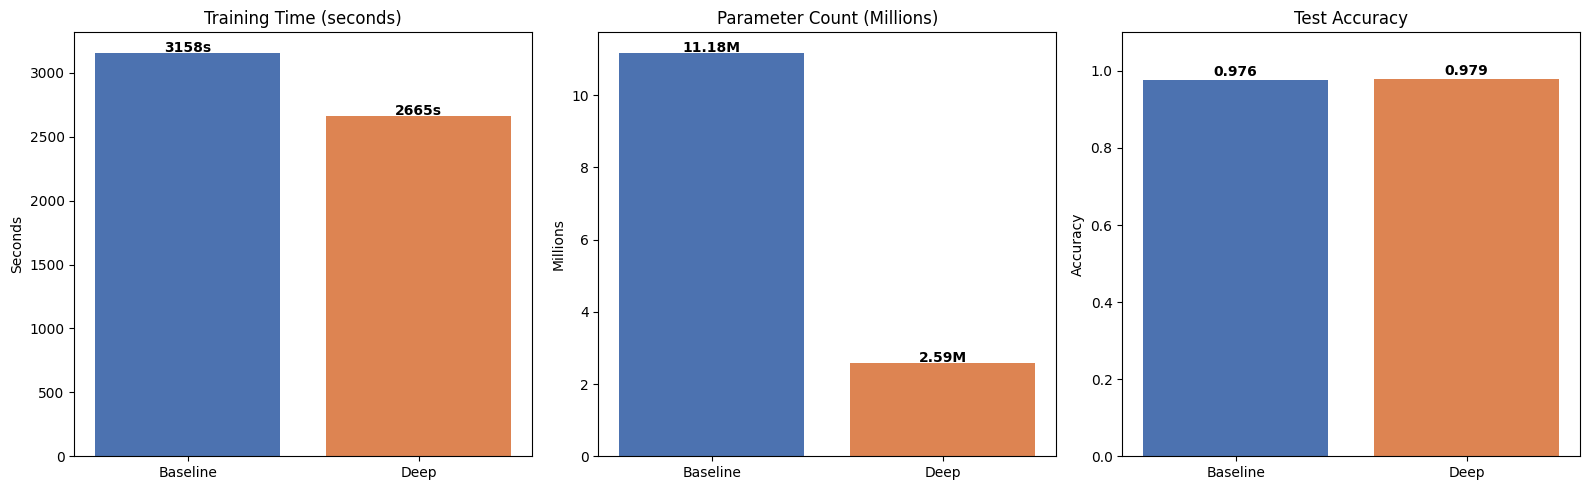

Baseline parameters : 11,179,791
Deep parameters     : 2,592,463

Hardware acceleration used: Google Colab GPU/TPU (recommended)


In [57]:
baseline_params = model_baseline.count_params()
deep_params     = model_deep.count_params()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_names = ['Baseline', 'Deep']

# Training time
axes[0].bar(models_names, [baseline_time, deep_time], color=['#4C72B0', '#DD8452'])
axes[0].set_title("Training Time (seconds)")
axes[0].set_ylabel("Seconds")
for i, v in enumerate([baseline_time, deep_time]):
    axes[0].text(i, v + 1, f"{v:.0f}s", ha='center', fontweight='bold')

# Parameter count
axes[1].bar(models_names, [baseline_params/1e6, deep_params/1e6], color=['#4C72B0', '#DD8452'])
axes[1].set_title("Parameter Count (Millions)")
axes[1].set_ylabel("Millions")
for i, v in enumerate([baseline_params/1e6, deep_params/1e6]):
    axes[1].text(i, v + 0.01, f"{v:.2f}M", ha='center', fontweight='bold')

# Test accuracy
axes[2].bar(models_names, [baseline_acc, deep_acc], color=['#4C72B0', '#DD8452'])
axes[2].set_title("Test Accuracy")
axes[2].set_ylabel("Accuracy")
axes[2].set_ylim(0, 1.1)
for i, v in enumerate([baseline_acc, deep_acc]):
    axes[2].text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Baseline parameters : {baseline_params:,}")
print(f"Deep parameters     : {deep_params:,}")
print(f"\nHardware acceleration used: Google Colab GPU/TPU (recommended)")

Optimizer Analysis (SGD vs Adam)

SGD

In [58]:
# ── SGD ─────────────────────────────────────────────────────────────────────
print("Training Deeper Model with SGD...")
model_sgd = build_deep_model(NUM_CLASSES)
model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

es_sgd = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0)
start_sgd = time.time()
history_sgd = model_sgd.fit(train_data, validation_data=val_data,
                             epochs=15, callbacks=[es_sgd], verbose=1)
sgd_time = time.time() - start_sgd

# ── Adam ─────────────────────────────────────────────────────────────────────
print("\nTraining Deeper Model with Adam...")
model_adam = build_deep_model(NUM_CLASSES)
model_adam.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

es_adam = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0)
start_adam = time.time()
history_adam = model_adam.fit(train_data, validation_data=val_data,
                               epochs=15, callbacks=[es_adam], verbose=1)
adam_time = time.time() - start_adam

Training Deeper Model with SGD...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 423ms/step - accuracy: 0.3703 - loss: 1.9368 - val_accuracy: 0.5253 - val_loss: 1.7839
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 410ms/step - accuracy: 0.7098 - loss: 0.9220 - val_accuracy: 0.4930 - val_loss: 2.0237
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 407ms/step - accuracy: 0.8007 - loss: 0.6597 - val_accuracy: 0.9013 - val_loss: 0.3215
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 193s 411ms/step - accuracy: 0.8532 - loss: 0.4867 - val_accuracy: 0.4667 - val_loss: 3.0181
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 193s 412ms/step - accuracy: 0.8833 - loss: 0.4250 - val_accuracy: 0.8450 - val_loss: 0.5698
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 410ms/step - accuracy: 0.9037 - loss: 0.3515 - val_accuracy: 0.8600 - val_loss: 0.5076
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 190s 405ms/step - accuracy: 0.9269 - loss: 0.2422 - val_accuracy: 0.9093 - val_loss: 0.3414

Training Deeper Model with Adam...
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 

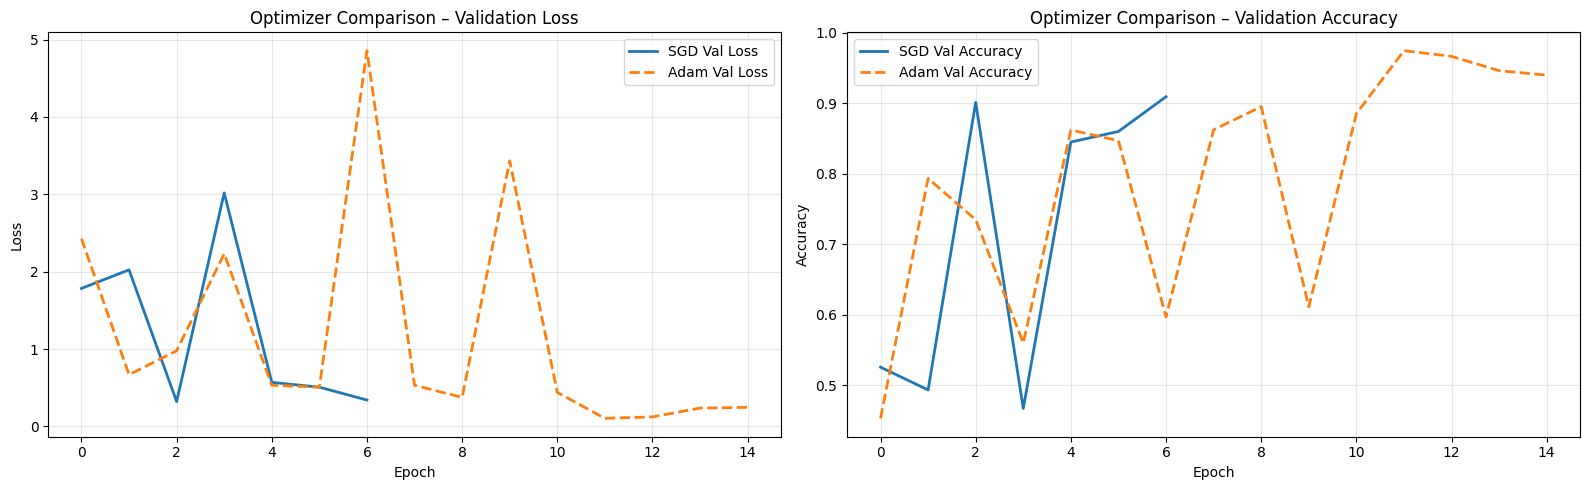


Optimizer         Test Accuracy     Time (s)
--------------------------------------------------
SGD (mom=0.9)            0.8950       1358.6
Adam                     0.9710       2917.3

Discussion:
- Adam uses adaptive learning rates per parameter → faster initial convergence.
- SGD with momentum can sometimes generalise better but converges slower.
- Adam is usually the preferred choice for image classification tasks.


In [59]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history_sgd.history['val_loss'],  label='SGD Val Loss',  linewidth=2)
axes[0].plot(history_adam.history['val_loss'], label='Adam Val Loss', linewidth=2, linestyle='--')
axes[0].set_title("Optimizer Comparison – Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_sgd.history['val_accuracy'],  label='SGD Val Accuracy',  linewidth=2)
axes[1].plot(history_adam.history['val_accuracy'], label='Adam Val Accuracy', linewidth=2, linestyle='--')
axes[1].set_title("Optimizer Comparison – Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate both
test_data.reset()
_, sgd_acc  = model_sgd.evaluate(test_data, verbose=0)
test_data.reset()
_, adam_acc = model_adam.evaluate(test_data, verbose=0)

print("\n" + "="*50)
print(f"{'Optimizer':<15} {'Test Accuracy':>15} {'Time (s)':>12}")
print("-"*50)
print(f"{'SGD (mom=0.9)':<15} {sgd_acc:>15.4f} {sgd_time:>12.1f}")
print(f"{'Adam':<15} {adam_acc:>15.4f} {adam_time:>12.1f}")
print("="*50)
print("\nDiscussion:")
print("- Adam uses adaptive learning rates per parameter → faster initial convergence.")
print("- SGD with momentum can sometimes generalise better but converges slower.")
print("- Adam is usually the preferred choice for image classification tasks.")

Ablation Study - Effect of Removing Dropout

In [60]:
def build_no_dropout_model(num_classes):
    """Deep model WITHOUT Dropout – for ablation study."""
    model = models.Sequential([
        layers.Conv2D(32,  (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
        layers.BatchNormalization(), layers.MaxPooling2D(2, 2),

        layers.Conv2D(64,  (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(2, 2),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(2, 2),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),

        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),

        layers.GlobalAveragePooling2D(),

        layers.Dense(512, activation='relu'),   # NO Dropout
        layers.Dense(256, activation='relu'),   # NO Dropout
        layers.Dense(128, activation='relu'),   # NO Dropout

        layers.Dense(num_classes, activation='softmax')
    ], name="Deep_No_Dropout")
    return model

model_no_drop = build_no_dropout_model(NUM_CLASSES)
model_no_drop.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

es_no_drop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0)
history_no_drop = model_no_drop.fit(
    train_data, validation_data=val_data, epochs=15,
    callbacks=[es_no_drop], verbose=1)

test_data.reset()
_, nodrop_acc = model_no_drop.evaluate(test_data, verbose=0)
print(f"\nNo-Dropout Model Test Accuracy: {nodrop_acc:.4f}")

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 209s 427ms/step - accuracy: 0.5514 - loss: 1.3773 - val_accuracy: 0.4440 - val_loss: 2.4229
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 194s 414ms/step - accuracy: 0.8323 - loss: 0.5170 - val_accuracy: 0.7713 - val_loss: 0.7465
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 190s 406ms/step - accuracy: 0.8912 - loss: 0.3516 - val_accuracy: 0.8363 - val_loss: 0.5613
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 409ms/step - accuracy: 0.9143 - loss: 0.2597 - val_accuracy: 0.8857 - val_loss: 0.3550
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 196s 418ms/step - accuracy: 0.9324 - loss: 0.2084 - val_accuracy: 0.8927 - val_loss: 0.3649
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 422ms/step - accuracy: 0.9374 - loss: 0.1981 - val_accuracy: 0.9013 - val_loss: 0.2984
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 429ms/step - accuracy: 0.9588 - loss: 0.1367 - val_accuracy: 0.9040 - val_loss: 0.3402
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 439ms/step - accuracy: 0.9542 -

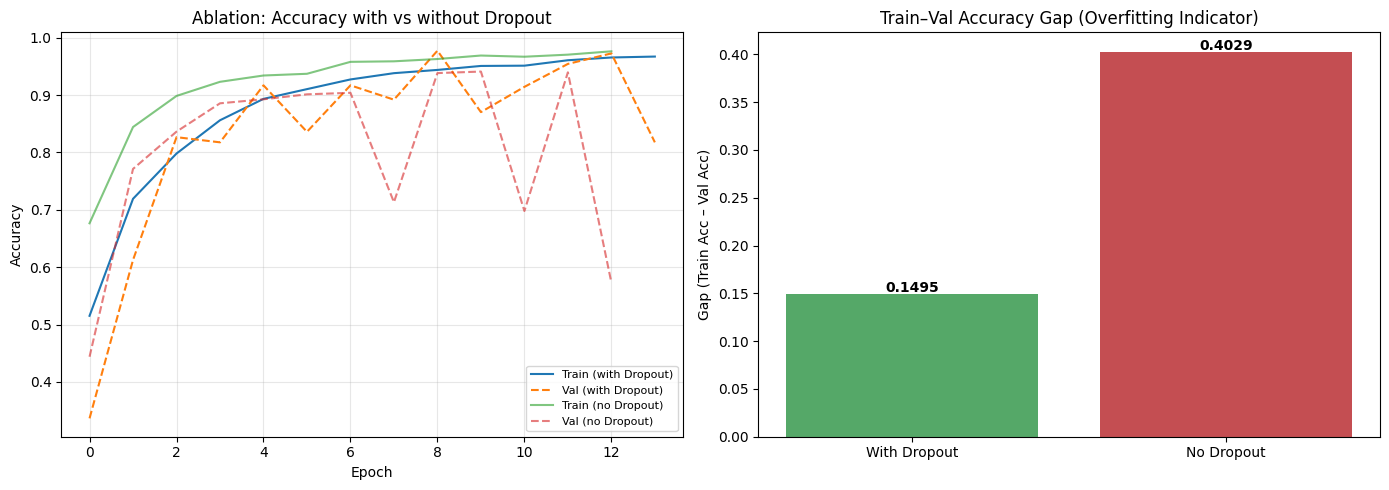

Overfitting gap WITH dropout   : 0.1495
Overfitting gap WITHOUT dropout: 0.4029

Conclusion: A larger gap without Dropout indicates more overfitting.
Dropout acts as a regulariser by randomly zeroing neurons during training.


In [61]:
# Compare overfitting gap: train acc - val acc
def overfitting_gap(history):
    return history.history['accuracy'][-1] - history.history['val_accuracy'][-1]

gap_with    = overfitting_gap(history_deep)
gap_without = overfitting_gap(history_no_drop)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_deep.history['accuracy'],        label='Train (with Dropout)')
axes[0].plot(history_deep.history['val_accuracy'],    label='Val (with Dropout)', linestyle='--')
axes[0].plot(history_no_drop.history['accuracy'],     label='Train (no Dropout)',  alpha=0.6)
axes[0].plot(history_no_drop.history['val_accuracy'], label='Val (no Dropout)',    linestyle='--', alpha=0.6)
axes[0].set_title("Ablation: Accuracy with vs without Dropout")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].bar(['With Dropout', 'No Dropout'], [gap_with, gap_without], color=['#55A868', '#C44E52'])
axes[1].set_title("Train–Val Accuracy Gap (Overfitting Indicator)")
axes[1].set_ylabel("Gap (Train Acc – Val Acc)")
for i, v in enumerate([gap_with, gap_without]):
    axes[1].text(i, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Overfitting gap WITH dropout   : {gap_with:.4f}")
print(f"Overfitting gap WITHOUT dropout: {gap_without:.4f}")
print("\nConclusion: A larger gap without Dropout indicates more overfitting.")
print("Dropout acts as a regulariser by randomly zeroing neurons during training.")

Challenges and Observations

In [62]:
print("="*60)
print("CHALLENGES AND OBSERVATIONS")
print("="*60)
print(f"""
1. Overfitting (Baseline):
   The baseline model, lacking regularisation, showed a growing
   gap between training and validation accuracy, indicating
   overfitting. Addressed in the deep model via Dropout and
   BatchNormalization.

2. Training Time:
   Baseline training time : {baseline_time:.1f}s
   Deep model training time: {deep_time:.1f}s
   Deeper models require significantly more compute.
   GPU/TPU acceleration (Google Colab) was recommended.

3. Learning Rate Sensitivity:
   SGD required careful tuning of the learning rate; too high
   caused oscillation, too low caused slow convergence.
   Adam was more robust to this.

4. Class Imbalance:
   If some vegetable classes have fewer samples, the model may
   under-perform on those classes (visible in the classification
   report per-class F1 scores).
""")

CHALLENGES AND OBSERVATIONS

1. Overfitting (Baseline):
   The baseline model, lacking regularisation, showed a growing
   gap between training and validation accuracy, indicating
   overfitting. Addressed in the deep model via Dropout and
   BatchNormalization.

2. Training Time:
   Baseline training time : 3158.0s
   Deep model training time: 2664.9s
   Deeper models require significantly more compute.
   GPU/TPU acceleration (Google Colab) was recommended.

3. Learning Rate Sensitivity:
   SGD required careful tuning of the learning rate; too high
   caused oscillation, too low caused slow convergence.
   Adam was more robust to this.

4. Class Imbalance:
   If some vegetable classes have fewer samples, the model may
   under-perform on those classes (visible in the classification
   report per-class F1 scores).



Part B - Transfer Learning

In [63]:
# MobileNetV2 requires its own preprocessing (pixel values in [-1, 1])
train_gen_mn = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_gen_mn  = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)
test_gen_mn = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)

train_data_mn = train_gen_mn.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

val_data_mn = val_gen_mn.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

test_data_mn = test_gen_mn.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

print(f"Classes: {NUM_CLASSES}")

Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Classes: 15


Load Pre-Trained Base Model & Add Classification Head

In [64]:
# Load MobileNetV2 WITHOUT the top classification layers
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,       # Remove original 1000-class output
    input_shape=(224, 224, 3)
)

print(f"MobileNetV2 base layers: {len(base_model.layers)}")
print(f"Original output shape  : {base_model.output_shape}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 base layers: 154
Original output shape  : (None, 7, 7, 1280)


Phase 1 - Feature Extraction (Freeze Convolutional Base)

In [65]:
# Freeze ALL base layers – retain ImageNet learned features
base_model.trainable = False
frozen_layers = sum(1 for l in base_model.layers if not l.trainable)
print(f"Frozen layers: {frozen_layers} / {len(base_model.layers)}")

# Build the custom classification head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)        # Pool spatial dims
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_mobilenet = Model(inputs=base_model.input, outputs=output, name="MobileNetV2_Transfer")

model_mobilenet.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print only the top layers
print("\nCustom head summary:")
for layer in model_mobilenet.layers[-7:]:
    print(f"  {layer.name:<35} trainable={layer.trainable}")

Frozen layers: 154 / 154

Custom head summary:
  out_relu                            trainable=False
  global_average_pooling2d_4          trainable=True
  dense_40                            trainable=True
  dropout_9                           trainable=True
  dense_41                            trainable=True
  dropout_10                          trainable=True
  dense_42                            trainable=True


Phase 1: Feature Extraction (base frozen)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


2026-05-14 09:26:51.160888: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 09:26:51.298595: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


308/469 ━━━━━━━━━━━━━━━━━━━━ 59s 368ms/step - accuracy: 0.7012 - loss: 0.9870

2026-05-14 09:28:56.579482: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 09:28:56.716743: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


469/469 ━━━━━━━━━━━━━━━━━━━━ 226s 441ms/step - accuracy: 0.7644 - loss: 0.7790 - val_accuracy: 0.9960 - val_loss: 0.0141
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 408ms/step - accuracy: 0.9693 - loss: 0.0971 - val_accuracy: 0.9953 - val_loss: 0.0117
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 408ms/step - accuracy: 0.9789 - loss: 0.0732 - val_accuracy: 0.9967 - val_loss: 0.0113
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 408ms/step - accuracy: 0.9847 - loss: 0.0534 - val_accuracy: 0.9987 - val_loss: 0.0060
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 430ms/step - accuracy: 0.9888 - loss: 0.0394 - val_accuracy: 0.9970 - val_loss: 0.0094
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 425ms/step - accuracy: 0.9840 - loss: 0.0476 - val_accuracy: 0.9973 - val_loss: 0.0063
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 193s 411ms/step - accuracy: 0.9854 - loss: 0.0465 - val_accuracy: 0.9970 - val_loss: 0.0091
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 189s 404ms/step - accuracy: 0.9887 - loss: 0.03

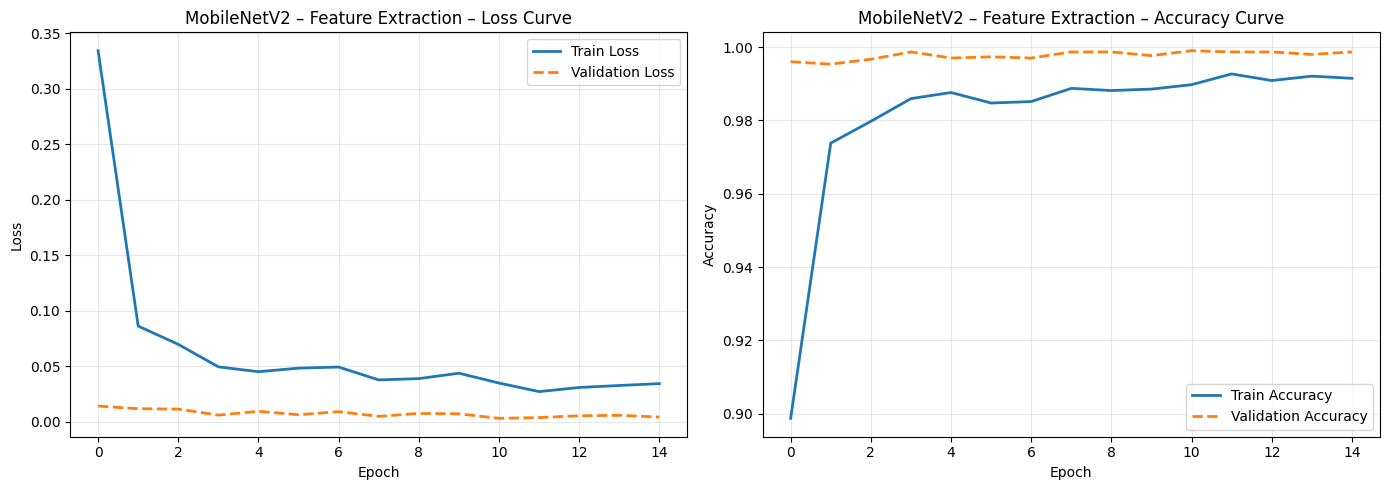

In [66]:
es_mn = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)

start_mn = time.time()

print("Phase 1: Feature Extraction (base frozen)")
history_mn_fe = model_mobilenet.fit(
    train_data_mn,
    validation_data=val_data_mn,
    epochs=15,
    callbacks=[es_mn]
)

mn_fe_time = time.time() - start_mn
print(f"\nFeature Extraction Training Time: {mn_fe_time:.1f}s")
plot_history(history_mn_fe, "MobileNetV2 – Feature Extraction")

Phase 2 - Fine Tuning (Unfreeze Last 30 Layers)

Trainable layers after unfreezing: 36

Phase 2: Fine-Tuning (last 30 base layers unfrozen)
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 228s 448ms/step - accuracy: 0.8862 - loss: 0.5290 - val_accuracy: 0.9987 - val_loss: 0.0092
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 194s 413ms/step - accuracy: 0.9679 - loss: 0.1106 - val_accuracy: 0.9990 - val_loss: 0.0081
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 410ms/step - accuracy: 0.9789 - loss: 0.0701 - val_accuracy: 0.9987 - val_loss: 0.0064
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 195s 415ms/step - accuracy: 0.9843 - loss: 0.0579 - val_accuracy: 0.9987 - val_loss: 0.0060
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 407ms/step - accuracy: 0.9874 - loss: 0.0400 - val_accuracy: 0.9987 - val_loss: 0.0050
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 190s 404ms/step - accuracy: 0.9889 - loss: 0.0381 - val_accuracy: 0.9983 - val_loss: 0.0054
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 409ms/step - accuracy: 0.9922 - loss: 0.0251 - val_accuracy: 0.9983 - va

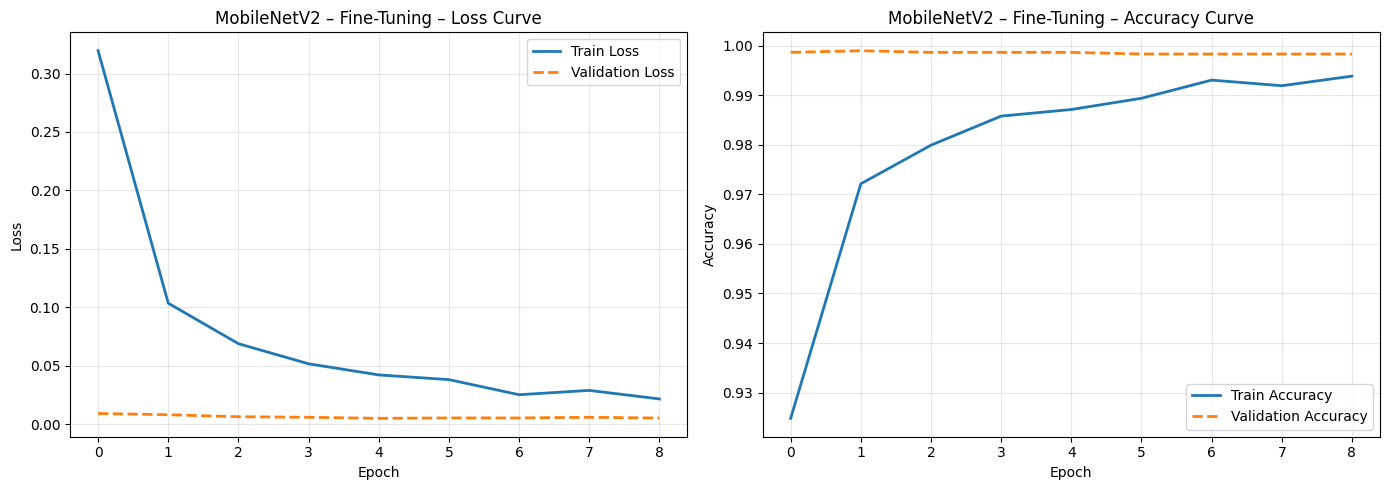

In [67]:
# Unfreeze the last 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_now = sum(1 for l in model_mobilenet.layers if l.trainable)
print(f"Trainable layers after unfreezing: {trainable_now}")

# Recompile with a LOWER learning rate to avoid catastrophic forgetting
model_mobilenet.compile(
    optimizer=Adam(learning_rate=1e-5),   # 100x lower than phase 1
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

es_ft = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)

start_ft = time.time()

print("\nPhase 2: Fine-Tuning (last 30 base layers unfrozen)")
history_mn_ft = model_mobilenet.fit(
    train_data_mn,
    validation_data=val_data_mn,
    epochs=10,
    callbacks=[es_ft]
)

mn_ft_time = time.time() - start_ft
mn_total_time = mn_fe_time + mn_ft_time
print(f"\nFine-Tuning Training Time: {mn_ft_time:.1f}s")
print(f"Total MobileNetV2 Time   : {mn_total_time:.1f}s")
plot_history(history_mn_ft, "MobileNetV2 – Fine-Tuning")

MobileNetV2 Evaluation


  MobileNetV2 Transfer Learning – Test Evaluation
  Test Loss    : 0.0052
  Test Accuracy: 0.9983 (99.83%)

Classification Report:
              precision    recall  f1-score   support

        Bean       1.00      1.00      1.00       200
Bitter_Gourd       1.00      0.99      0.99       200
Bottle_Gourd       1.00      1.00      1.00       200
     Brinjal       1.00      1.00      1.00       200
    Broccoli       0.99      0.99      0.99       200
     Cabbage       1.00      1.00      1.00       200
    Capsicum       1.00      1.00      1.00       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       1.00      0.99      0.99       200
    Cucumber       1.00      1.00      1.00       200
      Papaya       1.00      1.00      1.00       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       1.00      1.00      1.00       200
      Radish       1.00      1.00      1.00       200
      Tomato       1.00      1.00      1.00       200

  

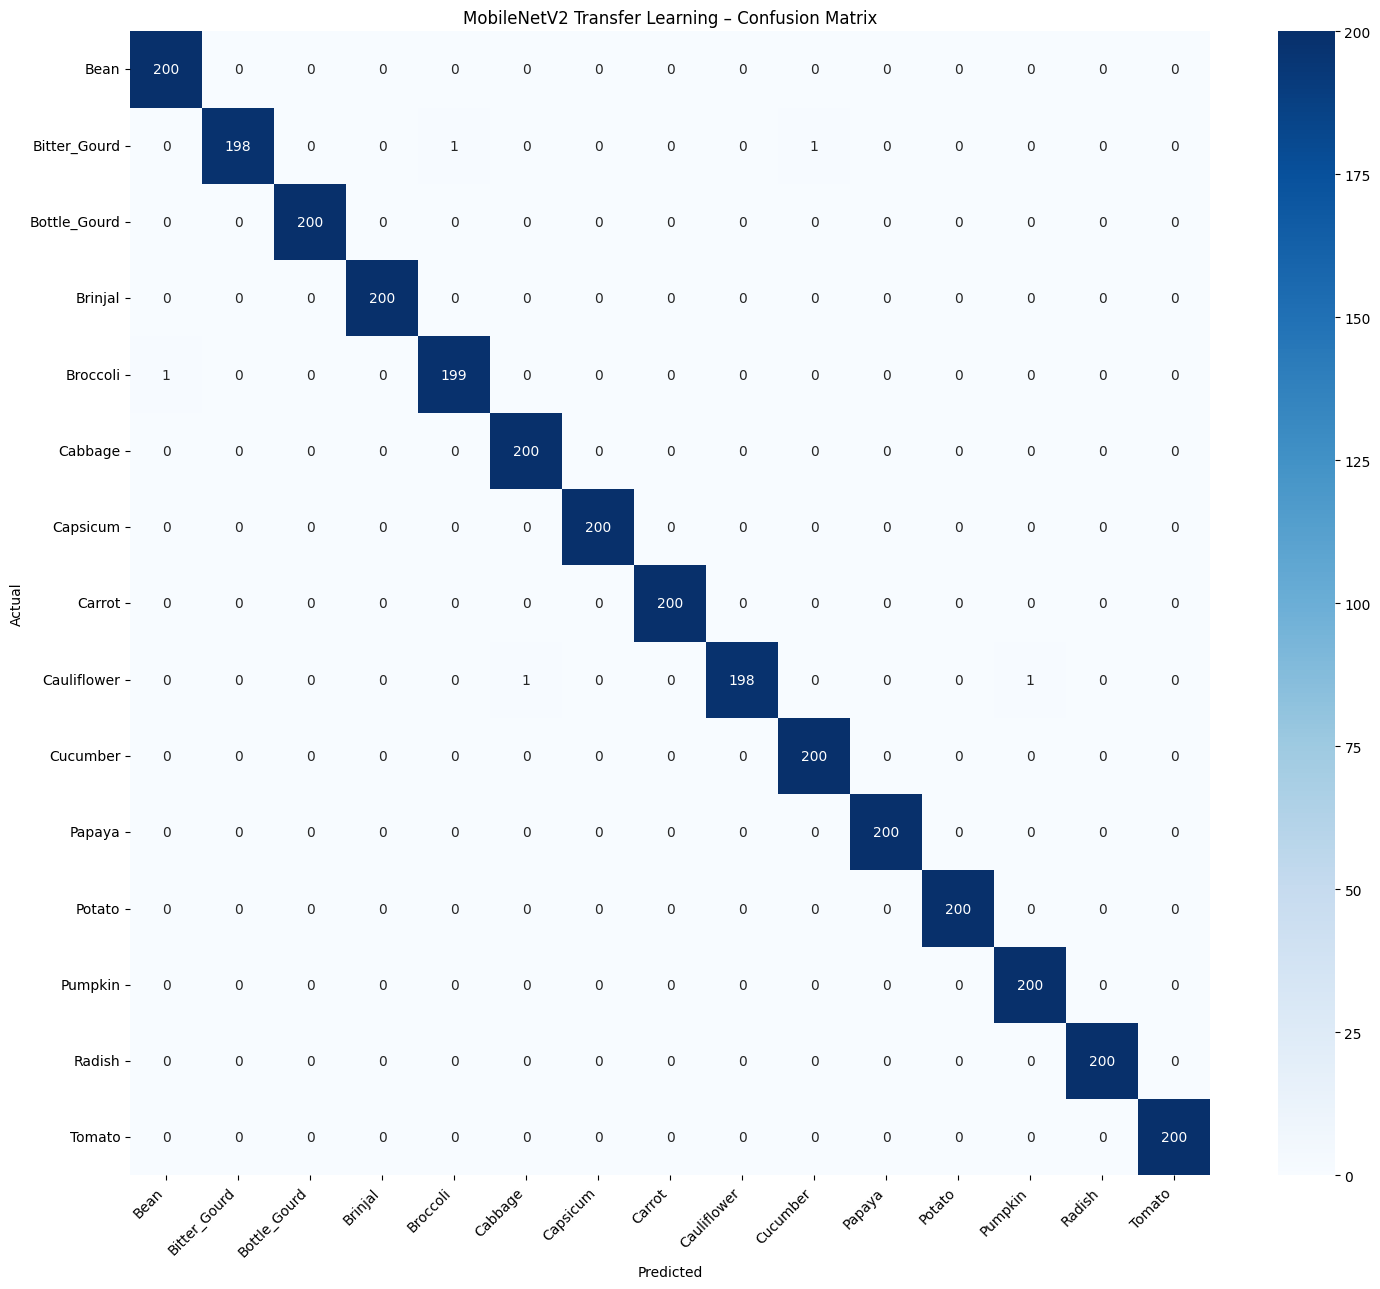

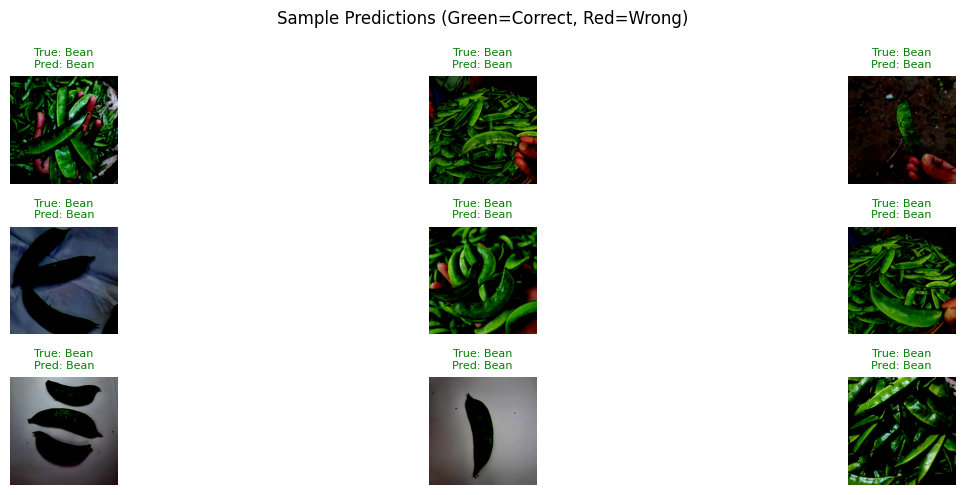

In [68]:
mn_loss, mn_acc, mn_preds, _ = evaluate_model(
    model_mobilenet, test_data_mn, "MobileNetV2 Transfer Learning")

infer_samples(model_mobilenet, test_data_mn)

Overall Performance Comparison

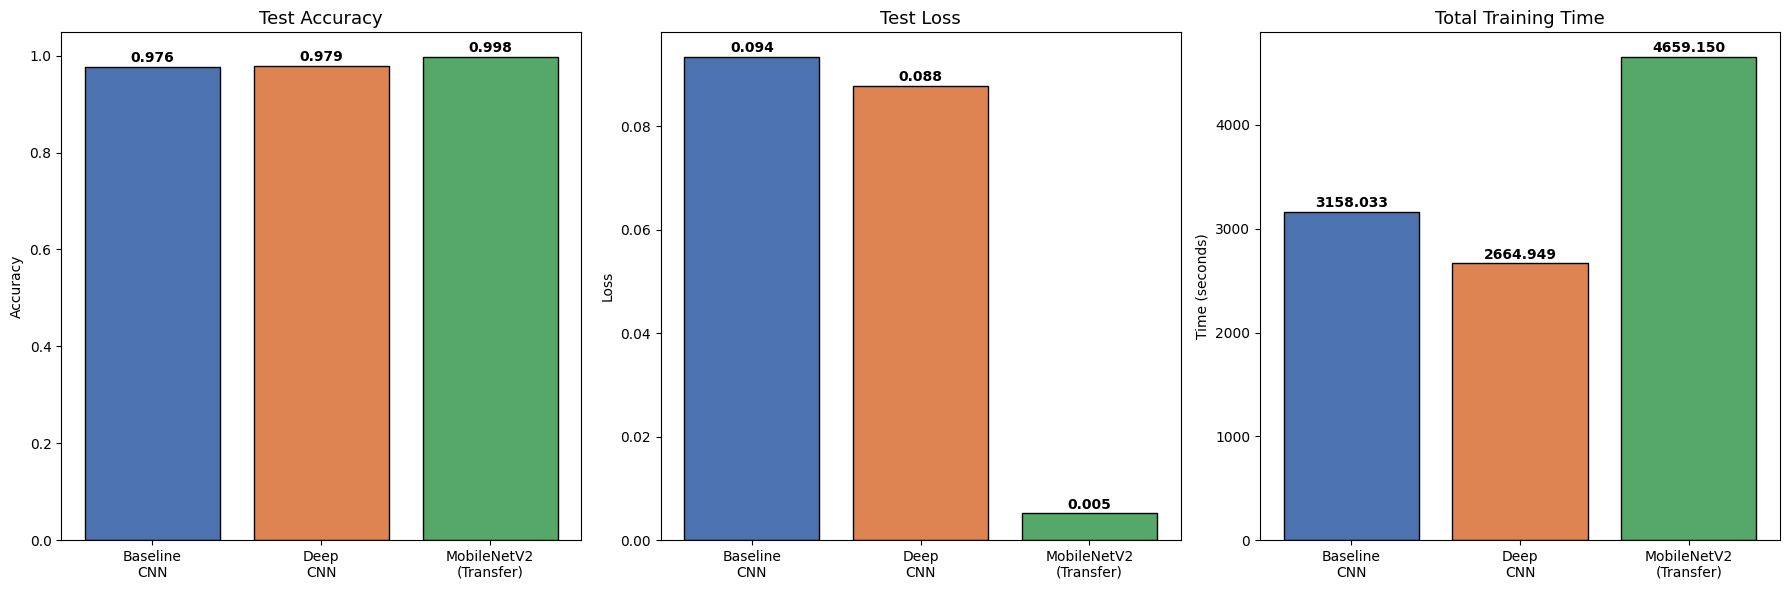


Model                       Test Acc   Test Loss   Time (s)
-----------------------------------------------------------------
Baseline CNN                  0.9763      0.0935     3158.0
Deep CNN                      0.9790      0.0878     2664.9
MobileNetV2 (Transfer)        0.9983      0.0052     4659.2

Best performing model: MobileNetV2 (Transfer) (0.9983 accuracy)

Discussion:
- Transfer learning (MobileNetV2) leverages millions of ImageNet training
  examples. It typically outperforms training from scratch, especially when
  the target dataset is small-to-medium sized.
- The Deep CNN with regularisation improves over the Baseline by reducing
  overfitting through BatchNorm and Dropout.
- Trade-off: MobileNetV2 requires more memory but converges faster per epoch.


In [69]:
model_labels = ['Baseline\nCNN', 'Deep\nCNN', 'MobileNetV2\n(Transfer)']
accuracies   = [baseline_acc, deep_acc, mn_acc]
losses       = [baseline_loss, deep_loss, mn_loss]
times        = [baseline_time, deep_time, mn_total_time]

colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, values, ylabel, title in zip(axes,
        [accuracies, losses, times],
        ['Accuracy', 'Loss', 'Time (seconds)'],
        ['Test Accuracy', 'Test Loss', 'Total Training Time']):
    bars = ax.bar(model_labels, values, color=colors, edgecolor='black')
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(ylabel)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                f"{v:.3f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Final summary table
print("\n" + "="*65)
print(f"{'Model':<25} {'Test Acc':>10} {'Test Loss':>11} {'Time (s)':>10}")
print("-"*65)
for name, acc, loss, t in zip(model_labels, accuracies, losses, times):
    print(f"{name.replace(chr(10), ' '):<25} {acc:>10.4f} {loss:>11.4f} {t:>10.1f}")
print("="*65)

best = model_labels[np.argmax(accuracies)].replace('\n', ' ')
print(f"\nBest performing model: {best} ({max(accuracies):.4f} accuracy)")
print("\nDiscussion:")
print("- Transfer learning (MobileNetV2) leverages millions of ImageNet training")
print("  examples. It typically outperforms training from scratch, especially when")
print("  the target dataset is small-to-medium sized.")
print("- The Deep CNN with regularisation improves over the Baseline by reducing")
print("  overfitting through BatchNorm and Dropout.")
print("- Trade-off: MobileNetV2 requires more memory but converges faster per epoch.")